<a href="https://colab.research.google.com/github/RenukanSapkale/code-alpha-project-1/blob/main/CodeAlpha(pr1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# =====================================================================
# 1. GENERATE SYNTHETIC FINANCIAL DATASET
# =====================================================================
print("📊 Creating synthetic financial history dataset...")
np.random.seed(42)
n_samples = 1000

data = {
    'Income_USD': np.random.randint(20000, 120000, size=n_samples),
    'Total_Debts_USD': np.random.randint(0, 50000, size=n_samples),
    'Payment_History_Score': np.random.randint(300, 850, size=n_samples), # Mimicking FICO score
    'Age': np.random.randint(21, 70, size=n_samples),
    'Utilization_Rate': np.random.uniform(0.0, 1.0, size=n_samples) # Credit card usage ratio
}

df = pd.DataFrame(data)

# Create a rule-based target variable: Creditworthy (1) or Risky (0)
# People with high payment scores and lower debts relative to income are more likely to be creditworthy
risk_score = (df['Payment_History_Score'] * 0.6) + (df['Income_USD'] / df['Total_Debts_USD'].replace(0, 1) * 0.1) - (df['Utilization_Rate'] * 200)
df['Creditworthy'] = (risk_score > np.median(risk_score)).astype(int)

print(df.head())
print("\n✅ Dataset generated successfully!")

# =====================================================================
# 2. SPLIT DATA AND TRAIN RANDOM FOREST CLASSIFIER
# =====================================================================
# Features (X) and Target (y)
X = df.drop(columns=['Creditworthy'])
y = df['Creditworthy']

# Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n⚡ Training set size: {X_train.shape[0]} samples")
print(f"⚡ Testing set size: {X_test.shape[0]} samples")

# Initialize and train the Random Forest Classifier
print("\n🤖 Training the Random Forest model...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✅ Model training complete!")

📊 Creating synthetic financial history dataset...
   Income_USD  Total_Debts_USD  Payment_History_Score  Age  Utilization_Rate  \
0       35795            48447                    608   62          0.697209   
1       20860            34529                    587   63          0.714327   
2       96820            10167                    606   61          0.461716   
3       74886            10554                    848   29          0.920995   
4       26265            17260                    651   44          0.694595   

   Creditworthy  
0             0  
1             0  
2             1  
3             1  
4             0  

✅ Dataset generated successfully!

⚡ Training set size: 800 samples
⚡ Testing set size: 200 samples

🤖 Training the Random Forest model...
✅ Model training complete!


In [2]:
# 3. ACCURACY ASSESSMENT & METRICS
# =====================================================================
# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probabilities needed for ROC-AUC

print("\n📋 --- MODEL EVALUATION METRICS --- 📋\n")

# 1. Print Precision, Recall, and F1-Score
print(classification_report(y_test, y_pred, target_names=['Risky (0)', 'Creditworthy (1)']))

# 2. Compute and print ROC-AUC Score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"⭐ ROC-AUC Score: {auc_score:.4f}")

# 3. Display Confusion Matrix
print("\n🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


📋 --- MODEL EVALUATION METRICS --- 📋

                  precision    recall  f1-score   support

       Risky (0)       0.97      0.97      0.97       110
Creditworthy (1)       0.97      0.97      0.97        90

        accuracy                           0.97       200
       macro avg       0.97      0.97      0.97       200
    weighted avg       0.97      0.97      0.97       200

⭐ ROC-AUC Score: 0.9982

🧩 Confusion Matrix:
[[107   3]
 [  3  87]]


/tmp/ipykernel_1672/277715110.py:22: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


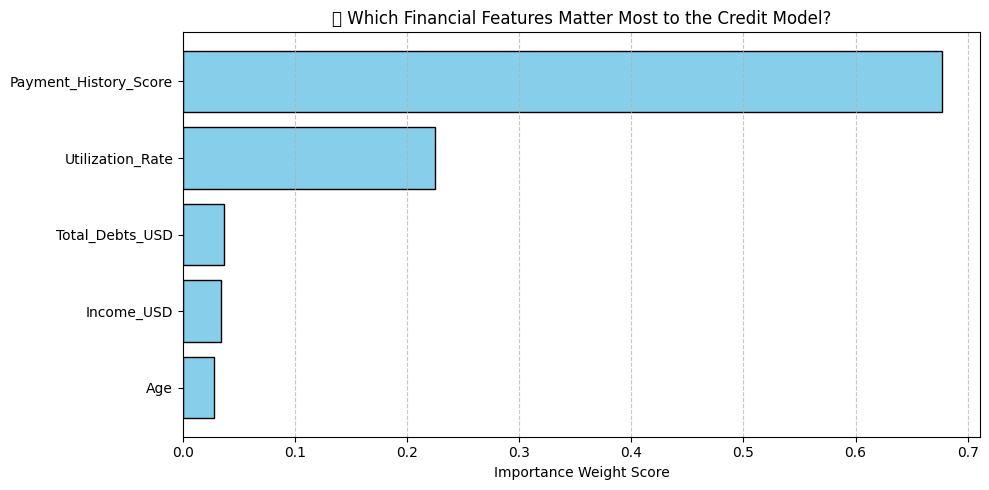

In [3]:
import matplotlib.pyplot as plt

# =====================================================================
# 4. FEATURE IMPORTANCE ANALYSIS
# =====================================================================
# Extract importance weights from our trained Random Forest model
importances = model.feature_importances_
feature_names = X.columns

# Organize into a clean Pandas DataFrame for easy sorting
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plot a horizontal bar chart
plt.figure(figsize=(10, 5))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='skyblue', edgecolor='black')
plt.xlabel('Importance Weight Score')
plt.title('🔍 Which Financial Features Matter Most to the Credit Model?')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [4]:
# 5. REAL-TIME CUSTOM CREDIT PREDICTOR
# =====================================================================
def predict_credit_status(income, debts, payment_score, age, utilization):
    """
    Takes individual financial stats and returns a credit assessment.
    """
    # Format the inputs exactly into the shape expected by the model
    custom_profile = pd.DataFrame([{
        'Income_USD': income,
        'Total_Debts_USD': debts,
        'Payment_History_Score': payment_score,
        'Age': age,
        'Utilization_Rate': utilization
    }])

    # Predict binary outcome and probabilities
    prediction = model.predict(custom_profile)[0]
    probability = model.predict_proba(custom_profile)[0][1]

    print("═══ FINANCIAL ASSESSMENT REPORT ═══")
    print(f"💰 Income: ${income:,} | 📉 Debt: ${debts:,}")
    print(f"📊 Payment Score: {payment_score} | 💳 Credit Card Utilization: {utilization*100:.1f}%")
    print("───────────────────────────────────")

    if prediction == 1:
        print(f"✅ STATUS: APPROVED (Confidence: {probability * 100:.1f}%)")
        print("💡 Recommendation: Low-risk application. Proceed with standard interest rates.")
    else:
        print(f"❌ STATUS: REJECTED (Risk Probability: {(1 - probability) * 100:.1f}%)")
        print("💡 Recommendation: High-risk indicators found. Review debt-to-income ratio or request a co-signer.")
    print("═══════════════════════════════════\n")

# --- TEST CASES ---
# Profile A: High income, clean history, low utilization
predict_credit_status(income=85000, debts=5000, payment_score=780, age=34, utilization=0.15)

# Profile B: Low income, heavy debt burden, high utilization
predict_credit_status(income=30000, debts=45000, payment_score=450, age=25, utilization=0.88)

═══ FINANCIAL ASSESSMENT REPORT ═══
💰 Income: $85,000 | 📉 Debt: $5,000
📊 Payment Score: 780 | 💳 Credit Card Utilization: 15.0%
───────────────────────────────────
✅ STATUS: APPROVED (Confidence: 100.0%)
💡 Recommendation: Low-risk application. Proceed with standard interest rates.
═══════════════════════════════════

═══ FINANCIAL ASSESSMENT REPORT ═══
💰 Income: $30,000 | 📉 Debt: $45,000
📊 Payment Score: 450 | 💳 Credit Card Utilization: 88.0%
───────────────────────────────────
❌ STATUS: REJECTED (Risk Probability: 94.0%)
💡 Recommendation: High-risk indicators found. Review debt-to-income ratio or request a co-signer.
═══════════════════════════════════

